<a href="https://colab.research.google.com/github/TommasoToti/MLCC-2026-Lab/blob/main/Lab4_KRLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Kernel Regularized Least Squares

Python >= 3.10

In this lab activity, we consider the extension of regularized least squares to non-linear problems using kernel functions.

A brief summary of the tasks:

1. Generate a simple non-linear dataset.
2. Use **linear** RLS to try to learn from such a dataset.
3. Use a **feature transformation** for learning with non-linear data.
4. Implement various kernel functions.
5. Implement kernel RLS.
6. Generate a more complex non-linear dataset.
7. Use kernel RLS for learning on non-linear data, and use cross-validation to find the best hyperparameters.

In [25]:
%matplotlib inline
import numpy as np
from numpy.random import Generator
import matplotlib.pyplot as plt
import scipy.spatial


def _check_random_generator(rng: int | Generator | None) -> Generator:
    """Convert rng into a np.random.Generator instance."""
    if rng is None:
        print("⚠️  Warning: Set the `rng` parameter to a NumPy random generator\n"
              "   (e.g. `np.random.default_rng(42)`) or specify a fixed seed to ensure\n"
              "   your results are reproducible. Proceeding with a random seed for now.")
        return np.random.default_rng()
    if isinstance(rng, Generator):
        return rng
    if isinstance(rng, (int, np.integer)):
        return np.random.default_rng(rng)

    raise TypeError(
        "rng must be None, an int seed, or a numpy.random.Generator"
    )


In [26]:
def calc_err(Ypred, Ytrue):
    return np.mean((Ypred-Ytrue)**2)

# Part 1: Learning with a simple non-linear dataset

## Generate quadratic data

In this lab we are going to use regression datasets where the target `Y` is **not a linear function** of the inputs `X`.

As a first example, see the following function to generate quadratic data.

In [27]:
def quadratic_data_gen(n, w, sigma_noise, rng=None):
    rng = _check_random_generator(rng)

    X = rng.uniform(-3, 3, size=(n, 1))
    Xsq = X ** 2
    noise = rng.normal(0, sigma_noise, size=(n, 1))

    # Here we can use scalar multiplication since in dimension 1
    Y = Xsq * w + noise

    return X, Y

Shape of x: (100, 1), shape of y: (100, 1)


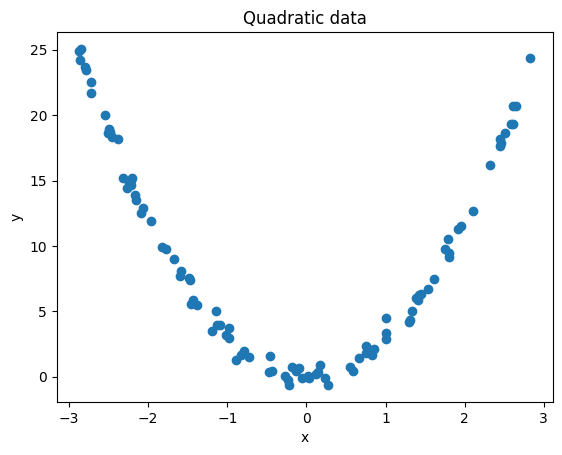

In [28]:
x_tr, y_tr = quadratic_data_gen(100, np.array([3]), 0.5, rng=2021)

print(f"Shape of x: {x_tr.shape}, shape of y: {y_tr.shape}")
fig, ax = plt.subplots()
ax.scatter(x_tr, y_tr)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Quadratic data")
plt.show()

## Task 1: Linear RLS

The implementation of linear regularized least-squares is given below in the functions `rls_train` and `rls_predict`.

Remember: regularized least-squares has the following form

$$(X_{tr}^\top X_{tr} + \lambda n I)w = X_{tr}^\top Y_{tr}$$


Tasks:
 - Use RLS to train a linear regressor for the quadratic data. Comment on the results.

In [29]:
def rls_train(x, y, reg_par):
    cov = x.T @ x + reg_par * x.shape[0] * np.eye(x.shape[1])
    rhs = x.T @ y
    w = np.linalg.solve(cov, rhs)
    return w

def rls_predict(x, w):
    return x @ w

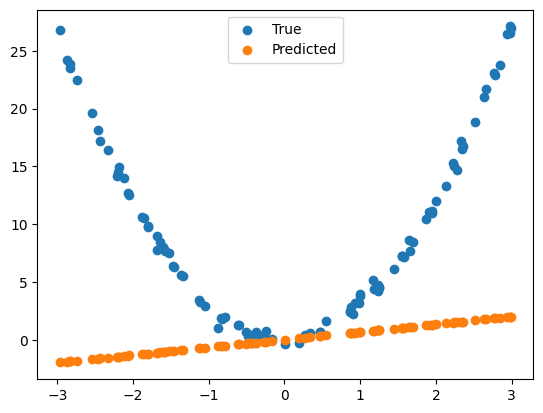

In [30]:
x_tr, y_tr = quadratic_data_gen(100, np.array([3]), 0.5, rng=302)

# TODO: put your code here
w = rls_train(x_tr, y_tr, 1)
pred_tr = rls_predict(x_tr, w)

fig, ax = plt.subplots()
ax.scatter(x_tr, y_tr, label="True")
ax.scatter(x_tr, pred_tr, label="Predicted")
ax.legend(loc="upper center")

Your comment: Line passing through the origin.


## Task 2: Feature transform

There is a simple way to use a linear algorithm for learning non-linear data: transform the input data in such a way that the problem becomes linear.

This is a simple fix in some cases, but it becomes cumbersome if the dataset is non-linear in a complex way.

Here we adopt this approach to train an RLS regressor on the quadratic dataset:

1. Generate the quadratic dataset.
2. Transform the data so that it becomes an `(n, 2)` matrix containing the original input and a transformed version of itself. Clearly, the correct transformation depends on the underlying function — in this case, a quadratic function.
3. Use the RLS algorithm on the new dataset.
4. Plot **and comment** on the results.

In [31]:
x_tr, y_tr = quadratic_data_gen(100, np.array([3]), 0.5, rng=302)

# TODO: Instead of just the given xs build a feature matrix with the xs and their squares:
trsf_x_tr = np.concatenate((x_tr, x_tr**2), axis=1)
assert trsf_x_tr.shape == (x_tr.shape[0], 2), f"Shape of x_tr is {x_tr.shape}. Expected ({x_tr.shape[0]}, 2)"

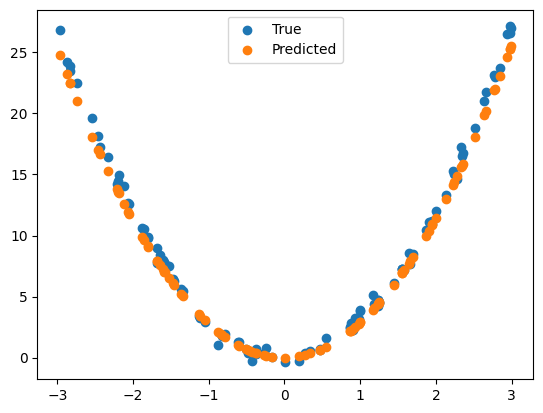

In [32]:
# TODO: Now train a linear regression function on the new data!
trsf_w_rls = rls_train(trsf_x_tr, y_tr, 1)
pred_tr = rls_predict(trsf_x_tr, trsf_w_rls)

fig, ax = plt.subplots()
ax.scatter(x_tr, y_tr, label="True")
ax.scatter(x_tr, pred_tr, label="Predicted")
ax.legend(loc="upper center");

# Part 2: Kernel Least Squares

## Implement 3 types of kernel

The `kernel_matrix` function takes as input two arrays of data, and outputs the kernel matrix evaluated at every pair of points.

You should implement it using the formulas seen in class for the following kernels:
 - linear kernel -- here the `param` argument can be ignored
 - polynomial kernel -- here the `param` argument is the exponent of the kernel
 - gaussian kernel -- here the `param` argument is the kernel length-scale ($\sigma$)

In [33]:
def squared_distances(X1, X2):
    """Compute the matrix of pairwise squared-distances between all points in X1 and in X2.
    """
    return scipy.spatial.distance.cdist(X1, X2, metric='sqeuclidean')

In [34]:
# TODO: put your code here
def kernel_matrix(X1, X2, kernel_type, param):
    # X1 : array of shape n x d
    # X2 : array of shape m x d
    if kernel_type == 'linear':
        return X1 @ X2.T
    elif kernel_type == 'polynomial':
        exponent = param
        return (X1 @ X2.T + 1)**exponent
    elif kernel_type == 'gaussian':
        lengthscale = param
        return np.exp(-squared_distances(X1, X2) / (2 * lengthscale**2))
    else:
        raise ValueError(kernel_type)

**Task:** Visualize the kernel (e.g. of the Gaussian type) for random data with different length-scales. What can you observe?

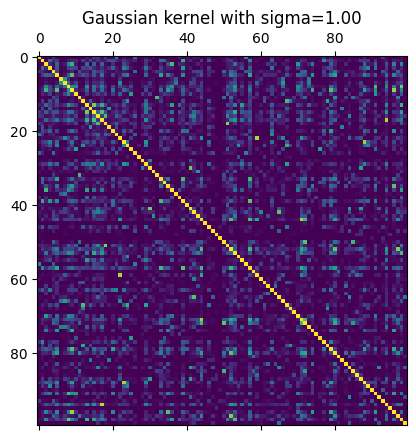

In [35]:
D = np.random.default_rng(42).standard_normal(size=(100, 5))
# TODO: put your code here
lengthscale = 1
K = kernel_matrix(D, D, "gaussian", lengthscale)
fig, ax = plt.subplots()
ax.matshow(K)
ax.set_title(f"Gaussian kernel with sigma={lengthscale:.2f}");

## Implement Kernel RLS

Remember that, given the kernel matrix $K$ with entries

$$K_{ij} = k(x_i, x_j), \quad i,j = 1,\dots,n,$$

KRLS learns a vector of coefficients with the following formula:

$$(K + n \lambda I)w = Y.$$

Predictions on a new point $\tilde{x}$ are then given by

$$f^{\mathrm{KRLS}}(\tilde{x}) = k(\tilde{x}, X^{\mathrm{train}}) w.$$

In [36]:
# TODO: put your code here
def krls_train(x, y, reg_par, kernel_type, kernel_par):
    K = kernel_matrix(x, x, kernel_type, kernel_par)
    w = np.linalg.solve(K + reg_par * x.shape[0] * np.eye(x.shape[0]), y)
    return w

def krls_predict(x_ts, x_tr, w, kernel_type, kernel_par):
    return kernel_matrix(x_ts, x_tr, kernel_type, kernel_par) @ w

Now test the functions you have implemented on the quadratic dataset.

**Tasks:**
 1. use the linear kernel, can you fit the data?
 2. use the polynomial kernel, test the effect of the kernel parameter on the results:
    - describe what happens with a low/high exponent in terms of the bias-variance tradeoff.
 3. use the polynomial kernel, but fix the kernel parameter. Test the effect of the regularization parameter
    - describe what happens with a low/high regularizer in terms of the bias-variance tradeoff

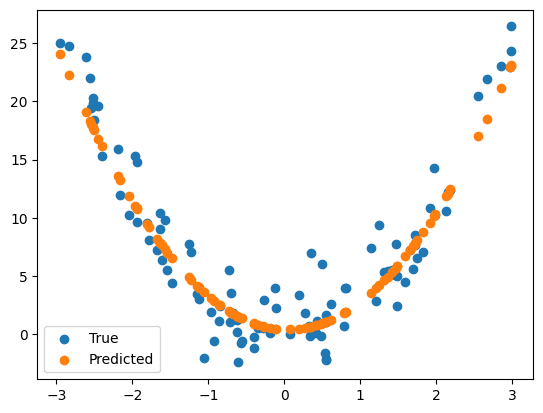

In [37]:
x_tr, y_tr = quadratic_data_gen(100, np.array([3]), 2.0, rng=212)

# TODO: put your code here
ker_par = 2
reg_param = 1
ker_type = "polynomial"

w_krls = krls_train(x_tr, y_tr, reg_param, ker_type, ker_par)
ypred_tr = krls_predict(x_tr, x_tr, w_krls, ker_type, ker_par)

fig, ax = plt.subplots()
ax.scatter(x_tr, y_tr, label="True")
ax.scatter(x_tr, ypred_tr, label="Predicted")
ax.legend(loc="best");

## Generating a more complex non-linear dataset

Define a function to generate a d-dimensional synthetic dataset where the targets `Y` depend non-linearly on the variables `X`.

The parameters of the function are:
 - n : the number of samples
 - d : the dimension of the samples
 - low_d : the lower-bound for the uniformly distributed samples
 - high_d : the higher-bound for the uniformly distributed samples
 - sigma_noise : standard deviation of Gaussian noise added to the targets

It should return:
 - X : 2D array of size n, d which fits in the desired bounds
 - Y : 2D array of size n, 1 which is a non-linear function of `X` (and a linear function of `w`)

Examples of non-linear regression functions:
 - polynomial dependence of the Y on the X data
 - logarithmic dependence
 - more complex transforms (e.g. trig functions)


In [38]:
def nonlinear_data_gen(n, d, w, low_d, high_d, sigma_noise, rng=None):
    rng = _check_random_generator(rng)

    X = rng.uniform(low=low_d, high=high_d, size=(n, d))
    assert X.shape == (n, d), "Shape of X incorrect"

    # Y is a non-linear function of X (log of sum of squares) and linear in w
    sum_of_squares_X = np.sum(X**2, axis=1, keepdims=True)
    # Add a small value to ensure the argument to log is positive and non-zero
    Y = np.log(sum_of_squares_X + 1e-6) * w

    assert Y.shape == (n, 1), "Shape of Y incorrect"

    # Add noise
    noise = rng.normal(0, sigma_noise, size=(n, 1))
    Y_noisy = Y + noise

    return X, Y_noisy

### Explanation of `np.log()` with `X (n,d)` input and `Y (n,1)` output

`np.log(X)` computes the natural logarithm element-wise. If `X` has a shape of `(n, d)`, applying `np.log(X)` directly will result in an array of the same shape `(n, d)`.

To achieve a `Y` of shape `(n, 1)` with a logarithmic dependence on `X` (where `X` is `(n, d)`), you need to transform or aggregate the `d` features of `X` into a single dimension for each sample `n` *before* or *during* the logarithmic operation.

For example, you could take the logarithm of a sum, product, or specific feature of `X` for each sample.

Here's a new function `nonlinear_data_gen_log` demonstrating how to create such a dataset.

Generated X shape: (100, 2)
Generated Y shape: (100, 1)


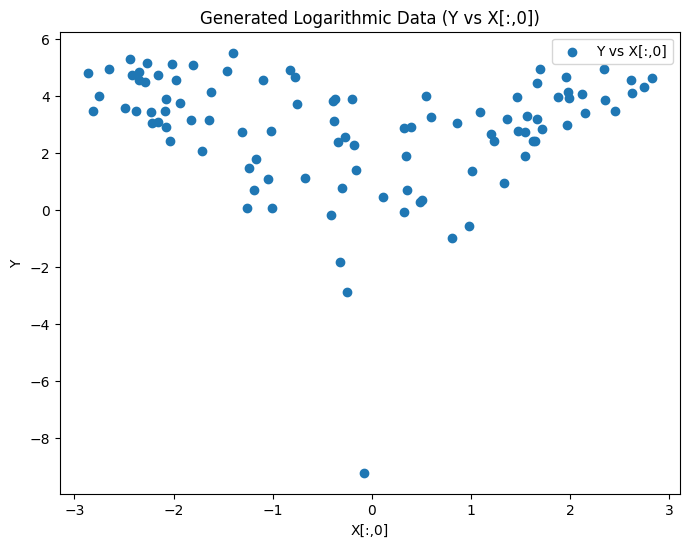

In [39]:
def nonlinear_data_gen_log(n, d, w_scalar, low_d, high_d, sigma_noise, rng=None):
    rng = _check_random_generator(rng)

    # Generate X values, ensuring they are positive for logarithm
    # We'll shift the range if low_d is non-positive or make sure sum is positive
    X = rng.uniform(low=low_d, high=high_d, size=(n, d))
    assert X.shape == (n, d), "Shape of X incorrect"

    # To ensure np.log() works and Y has shape (n,1):
    # Option 1: Log of the first feature, scaled by w_scalar
    # Y = np.log(np.abs(X[:, 0:1]) + 1e-6) * w_scalar # Add small epsilon to avoid log(0) and use abs

    # Option 2: Log of the sum of squared features, scaled by w_scalar
    # This is similar to the previous non-linear example, but with log
    sum_of_squares_X = np.sum(X**2, axis=1, keepdims=True)
    # Add a small value to ensure the argument to log is positive and non-zero
    Y = np.log(sum_of_squares_X + 1e-6) * w_scalar

    assert Y.shape == (n, 1), "Shape of Y incorrect"

    # Add noise
    noise = rng.normal(0, sigma_noise, size=(n, 1))
    Y_noisy = Y + noise

    return X, Y_noisy

# Example usage:
n_samples = 100
d_features = 2
w_val = 2
sigma = 0.5
low = -3
high = 3
rng_log = np.random.default_rng(42)

x_log, y_log = nonlinear_data_gen_log(n_samples, d_features, w_val, low, high, sigma, rng=rng_log)

print(f"Generated X shape: {x_log.shape}")
print(f"Generated Y shape: {y_log.shape}")

# Plotting example for a 1D or 2D X for visualization clarity
if d_features == 1:
    plt.figure(figsize=(8, 6))
    plt.scatter(x_log, y_log, label='Logarithmic Data')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Generated Logarithmic Data (d=1)')
    plt.legend()
    plt.show()
elif d_features == 2:
    # For 2D X, we can plot Y against one of the X dimensions or a combination
    plt.figure(figsize=(8, 6))
    plt.scatter(x_log[:, 0], y_log, label='Y vs X[:,0]')
    plt.xlabel('X[:,0]')
    plt.ylabel('Y')
    plt.title('Generated Logarithmic Data (Y vs X[:,0])')
    plt.legend()
    plt.show()


## KRLS and cross-validation
Now we will use KRLS and k-fold CV to learn on the complex non-linear datasets we have generated.

In this last part you will have to do the following:
 1. Generate a non-linear dataset, find the best hyperparameters (using e.g. the Gaussian kernel) with the training set, and then use them to make predictions on the test-set. Are you able to fit your data well?
 2. Analyse how the amount of noise (see the `sigma_noise` parameter of `nonlinear_data_gen`) influences the best lambda as selected by cross-validation. In particular answer to the following question:
     - How does the best lambda change as you increase/decrease the amount of noise in your dataset? Why?
     
    **Hint: keep the kernel parameter fixed for this third task, otherwise it might be very hard to see**

In [40]:
def _make_kfold_indices(n_tot, num_folds, rng):
    perm = rng.permutation(n_tot)
    return np.array_split(perm, num_folds)


def krls_kfold_valerr(x_tr, y_tr, split_idx, reg_par, kernel_type, kernel_par):
    """
    Compute train/val errors over *given* folds (split_idx is a list of index arrays).
    """
    n_tot = x_tr.shape[0]
    assert len(split_idx) > 1 and all(idx.dtype == int for idx in split_idx)
    assert sum(len(idx) for idx in split_idx) == n_tot

    tr_errs, val_errs = [], []
    for val_ids in split_idx:
        val_mask = np.zeros(n_tot, dtype=bool)
        val_mask[val_ids] = True

        kf_x_tr, kf_y_tr = x_tr[~val_mask], y_tr[~val_mask]
        kf_x_val, kf_y_val = x_tr[val_mask], y_tr[val_mask]

        w_krls = krls_train(kf_x_tr, kf_y_tr, reg_par=reg_par, kernel_type=kernel_type, kernel_par=kernel_par)
        pred_tr  = krls_predict(kf_x_tr,  kf_x_tr, w_krls, kernel_type=kernel_type, kernel_par=kernel_par)
        pred_val = krls_predict(kf_x_val, kf_x_tr, w_krls, kernel_type=kernel_type, kernel_par=kernel_par)

        tr_errs.append(calc_err(pred_tr,  kf_y_tr))
        val_errs.append(calc_err(pred_val, kf_y_val))

    return np.asarray(tr_errs), np.asarray(val_errs)


def krls_kfoldcv(x_tr, y_tr, num_folds, reg_par_list, kernel_type, kernel_par_list, rng=None):
    """
    Choose the best parameters for both the regularizer and the kernel parameter according to K-Fold CV.
    """
    n_tot = x_tr.shape[0]
    assert num_folds > 1 and num_folds <= n_tot

    # Precompute shared folds once for fair comparison
    rng = _check_random_generator(rng)
    split_idx = _make_kfold_indices(n_tot, num_folds, rng)

    errors = np.zeros((len(reg_par_list), len(kernel_par_list)))
    for i, reg_par in enumerate(reg_par_list):
        for j, kernel_par in enumerate(kernel_par_list):
            _, val_error = krls_kfold_valerr(x_tr, y_tr, split_idx, reg_par, kernel_type, kernel_par)
            errors[i, j] = np.mean(val_error)

    best_i, best_j = np.unravel_index(np.argmin(errors), errors.shape)
    best_reg_par = reg_par_list[best_i]
    best_kernel_par = kernel_par_list[best_j]
    best_err = errors[best_i, best_j]

    print(f"The best error (MSE={best_err:.5f}) was obtained with "
          f"lambda={best_reg_par}, kernel parameter={best_kernel_par}")

    return best_reg_par, best_kernel_par, best_err

In [41]:
# Data gen parameters
n_tr = 200
n_test = 100
d = 2
low_d = -2
high_d = 2
sigma_noise = 0.1
w_val = 3 # Added w_val for nonlinear_data_gen

# TODO: generate datasets
x_tr, y_tr = nonlinear_data_gen(n_tr, d, w_val, low_d, high_d, sigma_noise, rng=np.random.default_rng(2023))
x_test, y_test = nonlinear_data_gen(n_test, d, w_val, low_d, high_d, sigma_noise, rng=np.random.default_rng(2024))

# K_fold parameters
num_folds = 5
reg_par_list = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]
ker_type = 'gaussian'
ker_par_list = [0.01 * (10**i) for i in range(5)]

# TODO: Compute HERE the best kernel parameter and the best regularization parameter (use krls_kfoldcv!)
best_reg_par, best_kernel_par, _ = krls_kfoldcv(x_tr, y_tr, num_folds, reg_par_list, ker_type, ker_par_list, rng=np.random.default_rng(123))

# TODO: Now retrain on the whole of x_tr with the best parameters and test on x_ts!
w_krls = krls_train(x_tr, y_tr, best_reg_par, ker_type, best_kernel_par)
y_pred = krls_predict(x_test, x_tr, w_krls, ker_type, best_kernel_par)
test_error = calc_err(y_pred, y_test)
print(f'The MSE on the test data is: {test_error:.5f}')

The best error (MSE=0.28455) was obtained with lambda=0.001, kernel parameter=1.0
The MSE on the test data is: 0.14592


In [42]:
# TODO: Analyse the effect of noise!
w_val = 3 # Added w_val for nonlinear_data_gen

for noise in [0.001, 0.01, 0.1, 0.2, 0.5]:
    print(f'Noise {noise}:')
    # Generate datasets with current noise level
    x_tr, y_tr = nonlinear_data_gen(n_tr, d, w_val, low_d, high_d, noise, rng=np.random.default_rng(2023))
    x_test, y_test = nonlinear_data_gen(n_test, d, w_val, low_d, high_d, noise, rng=np.random.default_rng(2024))

    # TODO: Use krls_kfoldcv
    # Keeping kernel_par_list fixed as per hint for this task
    best_reg_par, best_kernel_par, _ = krls_kfoldcv(x_tr, y_tr, num_folds, reg_par_list, ker_type, ker_par_list, rng=np.random.default_rng(456))

    # TODO: Now retrain on the whole of x_tr with the best parameters and test on x_ts!
    w_krls = krls_train(x_tr, y_tr, best_reg_par, ker_type, best_kernel_par)
    y_pred = krls_predict(x_test, x_tr, w_krls, ker_type, best_kernel_par)
    test_error = calc_err(y_pred, y_test)
    print(f'The MSE on the test data is: {test_error:.5f}\n')

Noise 0.001:
The best error (MSE=0.27635) was obtained with lambda=0.001, kernel parameter=1.0
The MSE on the test data is: 0.13614

Noise 0.01:
The best error (MSE=0.27700) was obtained with lambda=0.001, kernel parameter=1.0
The MSE on the test data is: 0.13623

Noise 0.1:
The best error (MSE=0.29199) was obtained with lambda=0.001, kernel parameter=1.0
The MSE on the test data is: 0.14592

Noise 0.2:
The best error (MSE=0.32675) was obtained with lambda=0.001, kernel parameter=1.0
The MSE on the test data is: 0.17545

Noise 0.5:
The best error (MSE=0.54533) was obtained with lambda=0.001, kernel parameter=1.0
The MSE on the test data is: 0.38252

